## Customer Intent & Behavioral Segmentation

**Problem Statement**

Build a hybrid machine learning system combining classification and clustering to analyze customer behavior. The objective is to predict conversion probability and segment customers into meaningful behavioral groups to drive business decisions such as marketing optimization, targeting, and
revenue growth.

**Domain Knowledge**

In real-world digital platforms, customer behavior is captured through browsing, engagement, and transactional signals. Businesses leverage this data to understand intent, personalize experiences, and maximize conversions. This project simulates how companies like e-commerce and SaaS
platforms build intelligent systems to classify and segment users for strategic actions.

**Data Dictionary**

**Column**---------**Description**

age Customer age

pages_viewed Number of pages viewed

session_time Time spent per session

cart_additions Items added to cart

email_click_rate Email engagement rate

notification_response_rate Push notification engagement

estimated_order_value Behavior-based expected value

actual_order_value Actual purchase value

discount_usage_ratio Dependency on discounts

return_rate Likelihood of returning items

conversion Target variable (0/1)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [3]:
df=pd.read_csv('realistic_customer_dataset_v2.csv');

In [4]:
df.head()

,age,pages_viewed,session_time,cart_additions,email_click_rate,notification_response_rate,estimated_order_value,actual_order_value,discount_usage_ratio,return_rate,conversion
0,56,9,19.016948,3,0.288103,0.252493,1452.359468,1734.469174,0.409673,0.059776,1
1,46,7,21.708455,1,0.386205,0.262288,910.378796,0.000000,0.136150,0.055807,0
2,32,7,26.419601,2,0.305798,0.244928,457.348785,0.000000,0.316370,0.123034,0
3,25,15,48.576883,3,0.390958,0.094315,901.575221,793.487346,0.048466,0.154575,1
4,38,13,28.151052,4,0.473252,0.304194,1496.938331,1416.163483,0.198725,0.248266,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   pages_viewed                5000 non-null   int64  
 2   session_time                5000 non-null   float64
 3   cart_additions              5000 non-null   int64  
 4   email_click_rate            5000 non-null   float64
 5   notification_response_rate  5000 non-null   float64
 6   estimated_order_value       5000 non-null   float64
 7   actual_order_value          5000 non-null   float64
 8   discount_usage_ratio        5000 non-null   float64
 9   return_rate                 5000 non-null   float64
 10  conversion                  5000 non-null   int64  
dtypes: float64(7), int64(4)
memory usage: 429.8 KB


In [6]:
df.describe()

,age,pages_viewed,session_time,cart_additions,email_click_rate,notification_response_rate,estimated_order_value,actual_order_value,discount_usage_ratio,return_rate,conversion
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,38.662200,9.000000,27.013578,1.762600,0.300065,0.250117,960.398483,567.771420,0.288444,0.091228,0.548400
std,12.028492,2.812398,11.728744,1.133181,0.147765,0.100560,302.583739,571.609571,0.159022,0.083815,0.497702
min,18.000000,1.000000,3.423632,0.000000,0.000000,0.000000,100.000000,0.000000,0.003082,0.000022,0.000000
25%,28.000000,7.000000,18.417825,1.000000,0.197670,0.182612,746.003934,0.000000,0.163613,0.028234,0.000000
50%,39.000000,9.000000,25.176458,2.000000,0.297813,0.251015,945.798762,607.209803,0.268077,0.067608,1.000000
75%,49.000000,11.000000,33.728623,2.000000,0.399187,0.319397,1153.648745,1044.695743,0.393781,0.130160,1.000000
max,59.000000,21.000000,77.657713,7.000000,0.810281,0.624538,2293.180992,2495.204930,0.853329,0.600371,1.000000


In [7]:
df.shape

(5000, 11)

In [8]:
df.columns

Index(['age', 'pages_viewed', 'session_time', 'cart_additions',
       'email_click_rate', 'notification_response_rate',
       'estimated_order_value', 'actual_order_value', 'discount_usage_ratio',
       'return_rate', 'conversion'],
      dtype='object')

In [11]:
df.dtypes

age                             int64
pages_viewed                    int64
session_time                  float64
cart_additions                  int64
email_click_rate              float64
notification_response_rate    float64
estimated_order_value         float64
actual_order_value            float64
discount_usage_ratio          float64
return_rate                   float64
conversion                      int64
dtype: object

In [16]:
df.isnull().sum()

age                           0
pages_viewed                  0
session_time                  0
cart_additions                0
email_click_rate              0
notification_response_rate    0
estimated_order_value         0
actual_order_value            0
discount_usage_ratio          0
return_rate                   0
conversion                    0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [19]:
df[num_cols]

,age,pages_viewed,session_time,cart_additions,email_click_rate,notification_response_rate,estimated_order_value,actual_order_value,discount_usage_ratio,return_rate,conversion
0,56,9,19.016948,3,0.288103,0.252493,1452.359468,1734.469174,0.409673,0.059776,1
1,46,7,21.708455,1,0.386205,0.262288,910.378796,0.000000,0.136150,0.055807,0
2,32,7,26.419601,2,0.305798,0.244928,457.348785,0.000000,0.316370,0.123034,0
3,25,15,48.576883,3,0.390958,0.094315,901.575221,793.487346,0.048466,0.154575,1
4,38,13,28.151052,4,0.473252,0.304194,1496.938331,1416.163483,0.198725,0.248266,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,32,11,37.655209,2,0.446661,0.218037,830.583157,0.000000,0.076810,0.180201,0
4996,36,9,33.550004,2,0.303797,0.013033,648.900255,659.201133,0.363168,0.202928,1
4997,52,12,36.384110,2,0.312071,0.451971,980.957012,1088.551605,0.234920,0.230827,1
4998,34,7,23.319996,1,0.260831,0.251807,541.841282,0.000000,0.247251,0.179923,0


In [20]:
def cap_outliers(col):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return df[col].clip(lower, upper)

for col in num_cols:
    df[col] = cap_outliers(col)

In [22]:
df[col]

0       1
1       0
2       0
3       1
4       1
       ..
4995    0
4996    1
4997    1
4998    0
4999    0
Name: conversion, Length: 5000, dtype: int64

In [23]:
df['engagement_score']=(df['pages_viewed'] * 0.25 +df['session_time'] * 0.35 +df['email_click_rate'] * 0.2 +df['notification_response_rate'] * 0.2)
df['engagement_score']    

0        9.014051
1        9.477658
2       11.107006
3       20.848964
4       13.258358
          ...    
4995    16.062263
4996    14.055867
4997    15.887247
4998    10.014526
4999    14.787218
Name: engagement_score, Length: 5000, dtype: float64

In [24]:
df['purchase_intent']=(df['cart_additions'] * 0.5 +df['estimated_order_value'] * 0.5)
df['purchase_intent']

0       727.679734
1       455.689398
2       229.674392
3       452.287610
4       750.219165
           ...    
4995    416.291579
4996    325.450128
4997    491.478506
4998    271.420641
4999    243.334115
Name: purchase_intent, Length: 5000, dtype: float64

In [25]:
df['discount_sensitivity']=(df['discount_usage_ratio'] * df['cart_additions'])
df['discount_sensitivity']

0       1.229019
1       0.136150
2       0.632740
3       0.145398
4       0.695538
          ...   
4995    0.153619
4996    0.726336
4997    0.469840
4998    0.247251
4999    0.380660
Name: discount_sensitivity, Length: 5000, dtype: float64

In [26]:
df['value_gap']=df['estimated_order_value']-df['actual_order_value']
df['value_gap']

0      -282.109706
1       910.378796
2       457.348785
3       108.087875
4        80.774847
           ...    
4995    830.583157
4996    -10.300877
4997   -107.594593
4998    541.841282
4999    485.668230
Name: value_gap, Length: 5000, dtype: float64

In [27]:
df['engagement_efficiency']=df['pages_viewed']/(df['session_time'] + 1)
df['engagement_efficiency']

0       0.449619
1       0.308255
2       0.255292
3       0.302560
4       0.445953
          ...   
4995    0.284567
4996    0.260492
4997    0.320992
4998    0.287829
4999    0.246858
Name: engagement_efficiency, Length: 5000, dtype: float64

In [28]:
df['risk_score']=df['return_rate']*df['actual_order_value']
df['risk_score']

0       103.680037
1         0.000000
2         0.000000
3       122.653242
4       351.585613
           ...    
4995      0.000000
4996    133.770220
4997    251.267101
4998      0.000000
4999      0.000000
Name: risk_score, Length: 5000, dtype: float64

In [29]:
skewed_cols = ['session_time', 'estimated_order_value', 'actual_order_value']
for col in skewed_cols:
    df[col] = np.log1p(df[col])

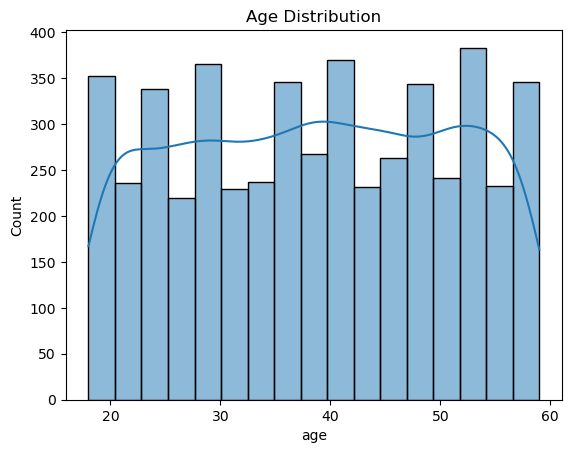

In [30]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

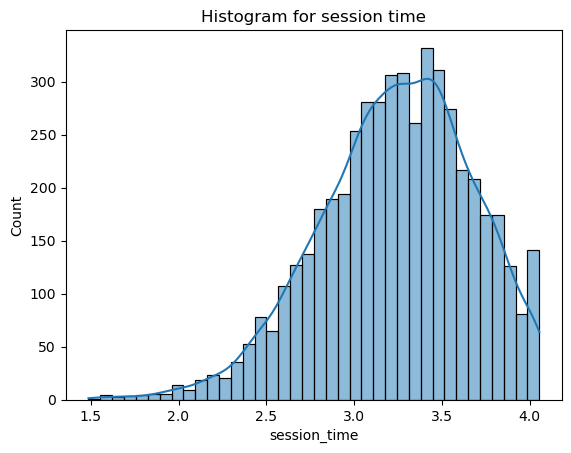

In [31]:
sns.histplot(df['session_time'], kde=True)
plt.title('Histogram for session time')
plt.show()

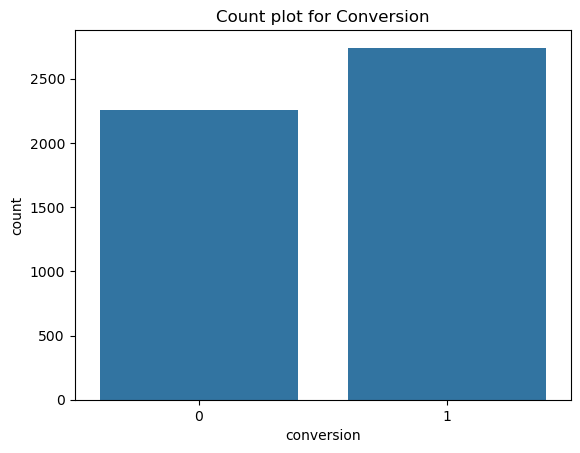

In [33]:
sns.countplot(x='conversion', data=df)
plt.title('Count plot for Conversion')
plt.show()

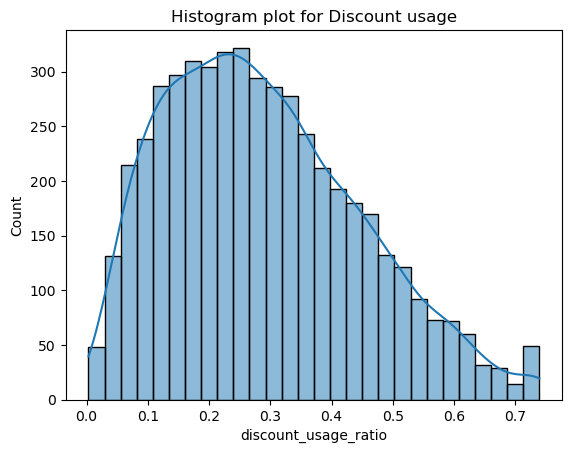

In [34]:
sns.histplot(df['discount_usage_ratio'], kde=True)
plt.title('Histogram plot for Discount usage')
plt.show()

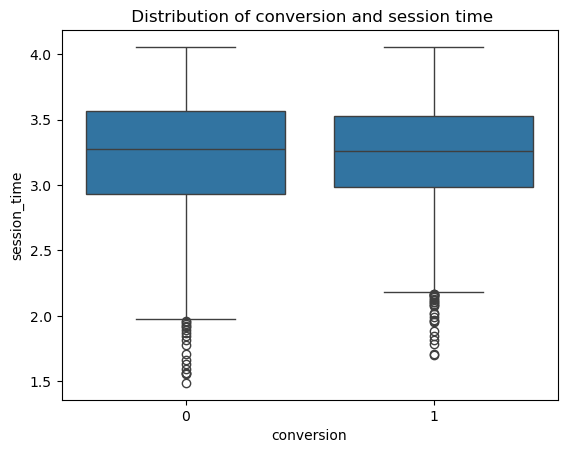

In [35]:
sns.boxplot(x='conversion', y='session_time', data=df)
plt.title(' Distribution of conversion and session time')
plt.show()

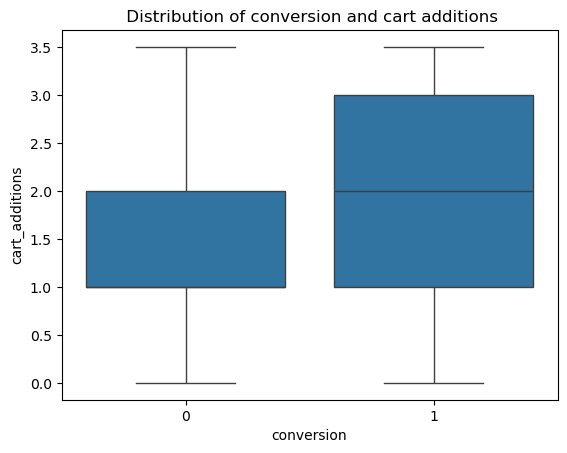

In [36]:
sns.boxplot(x='conversion', y='cart_additions', data=df)
plt.title(' Distribution of conversion and cart additions')
plt.show()

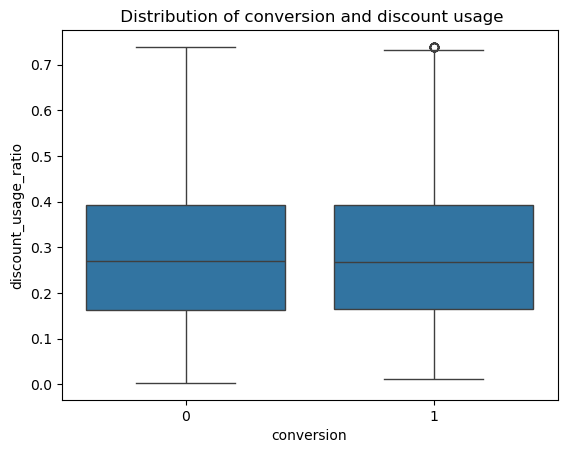

In [37]:
sns.boxplot(x='conversion', y='discount_usage_ratio', data=df)
plt.title(' Distribution of conversion and discount usage')
plt.show()

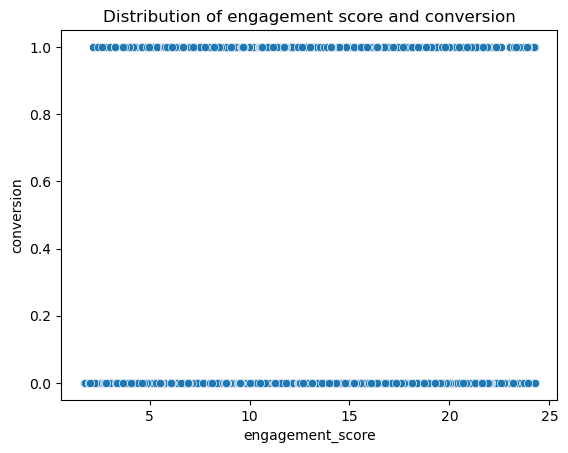

In [38]:
sns.scatterplot(x='engagement_score', y='conversion', data=df)
plt.title('Distribution of engagement score and conversion')
plt.show()

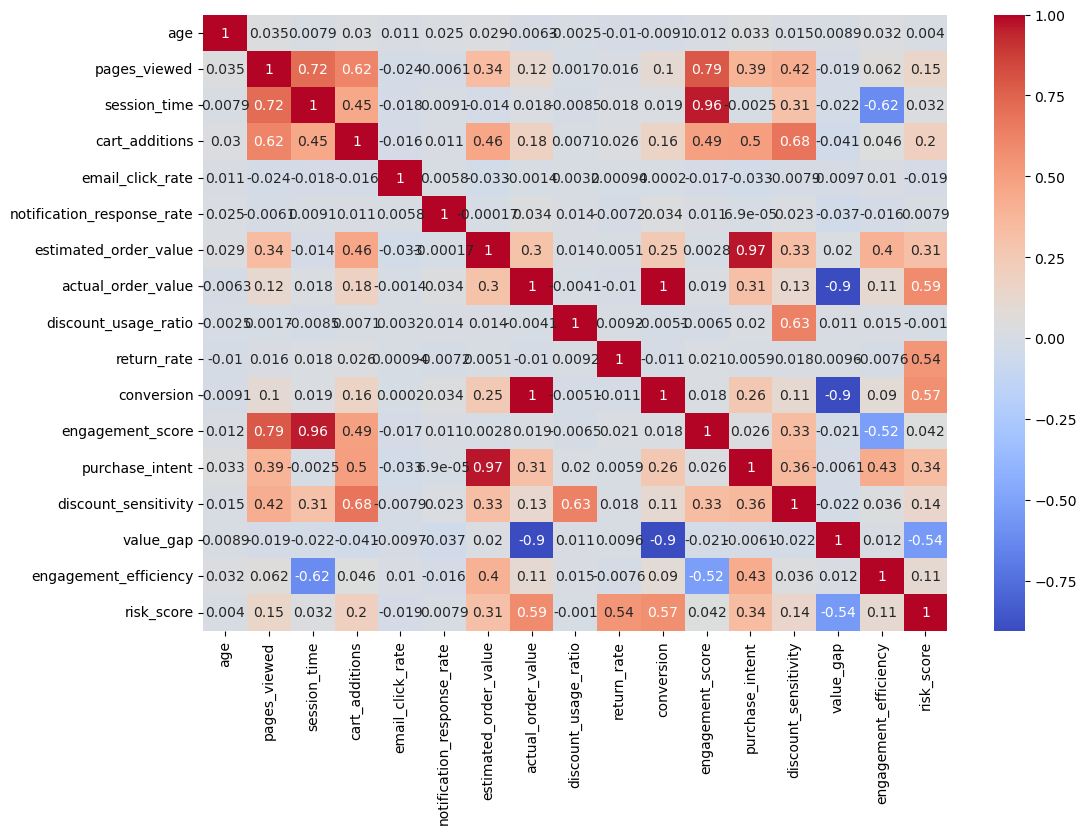

In [39]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

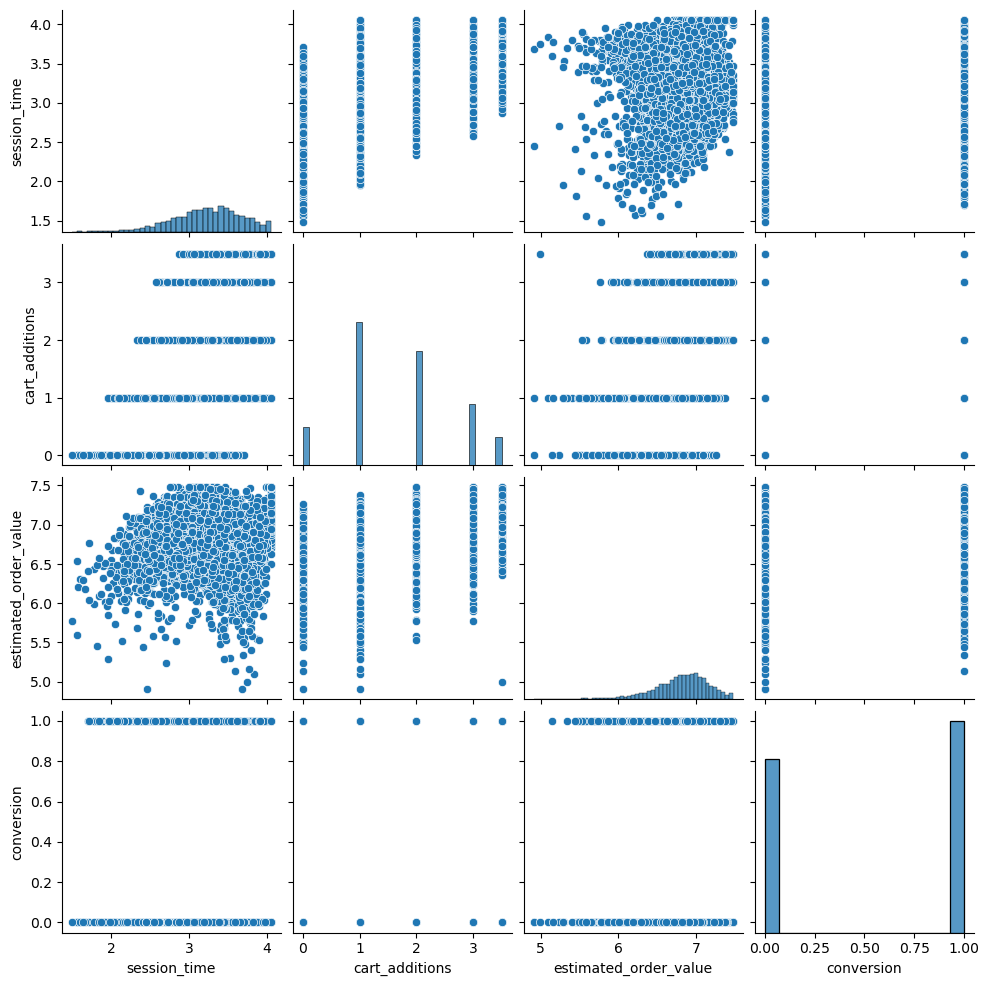

In [40]:
sns.pairplot(df[['session_time','cart_additions','estimated_order_value','conversion']])
plt.show()

In [41]:
scaler = StandardScaler()
features = df.drop(columns=['conversion'])
scaled_features = scaler.fit_transform(features)
X_scaled = pd.DataFrame(scaled_features, columns=features.columns)

In [42]:
df = pd.get_dummies(df, drop_first=True)

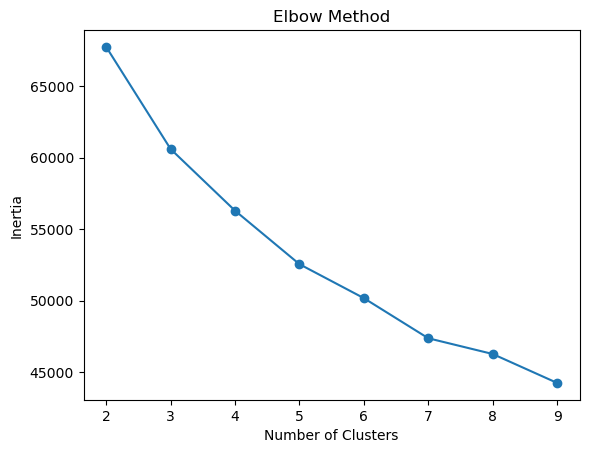

In [43]:
inertia = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.plot(range(2,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [44]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

In [45]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

In [46]:
agg = AgglomerativeClustering(n_clusters=4)
df['hier_cluster'] = agg.fit_predict(X_scaled)

In [48]:
cluster_profile = df.groupby('kmeans_cluster').mean()
cluster_profile

,age,pages_viewed,session_time,cart_additions,email_click_rate,notification_response_rate,estimated_order_value,actual_order_value,discount_usage_ratio,return_rate,conversion,engagement_score,purchase_intent,discount_sensitivity,value_gap,engagement_efficiency,risk_score,dbscan_cluster,hier_cluster
kmeans_cluster,,,,,,,,,,,,,,,,,,,
0,39.107168,9.073765,3.104482,1.916841,0.303637,0.257557,7.050627,7.060002,0.283588,0.104811,1.000000,10.148146,587.740323,0.529546,-19.002988,0.408632,122.411996,-0.272791,1.969381
1,38.341014,9.162826,3.532016,1.373656,0.307889,0.249961,6.489224,3.099584,0.256340,0.079224,0.475422,14.286310,343.035631,0.335699,348.923518,0.264519,22.561035,0.155146,1.392473
2,38.426756,6.636024,2.817639,0.989537,0.297011,0.241421,6.744559,1.200921,0.279590,0.085346,0.182362,7.606086,442.897721,0.264146,748.163600,0.389836,7.648411,0.289238,0.550822
3,38.763814,12.057421,3.655288,2.869989,0.287207,0.250981,6.998056,3.355458,0.352843,0.081902,0.478873,16.797402,563.052933,0.984347,575.962475,0.315387,38.166245,-0.510293,1.585049


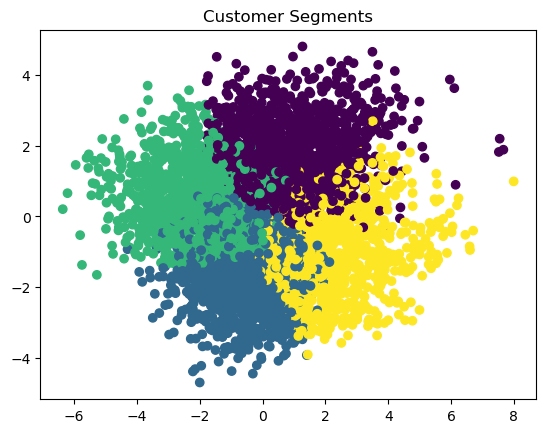

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['kmeans_cluster'])
plt.title("Customer Segments")
plt.show()

In [51]:
X = df.drop(columns=['conversion'])
y = df['conversion']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [55]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_results = evaluate_model(lr, X_test, y_test)
print("Logistic Regression:", lr_results)

Logistic Regression: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0, 'ROC-AUC': np.float64(1.0)}


In [56]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)
dt_results = evaluate_model(dt, X_test, y_test)
print("Decision Tree:", dt_results)

Decision Tree: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0, 'ROC-AUC': np.float64(1.0)}


In [57]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_results = evaluate_model(rf, X_test, y_test)
print("Random Forest:", rf_results)

Random Forest: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0, 'ROC-AUC': np.float64(0.9999999999999999)}


In [58]:
xgb_model = xgb.XGBClassifier(eval_metric='logloss',use_label_encoder=False)
xgb_model.fit(X_train, y_train)
xgb_results = evaluate_model(xgb_model, X_test, y_test)
print("XGBoost:", xgb_results)

XGBoost: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0, 'ROC-AUC': np.float64(1.0)}


C:\Users\admin\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:37:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [59]:
results_df = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,
    xgb_results
], index=['Logistic Regression','Decision Tree','Random Forest','XGBoost'])
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,1.0,1.0,1.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0,1.0
XGBoost,1.0,1.0,1.0,1.0,1.0


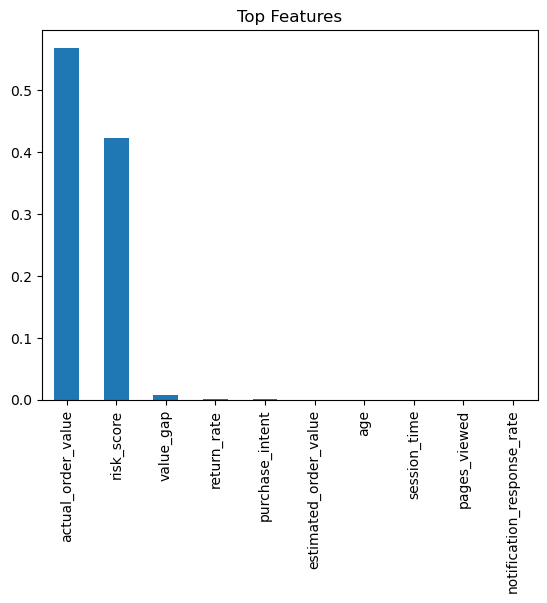

In [60]:
importance = xgb_model.feature_importances_
feat_names = X.columns
feat_imp = pd.Series(importance, index=feat_names).sort_values(ascending=False)
feat_imp.head(10).plot(kind='bar')
plt.title("Top Features")
plt.show()

In [61]:
df['conversion_prob'] = xgb_model.predict_proba(X)[:,1]

In [62]:
df['segment'] = df['kmeans_cluster']

In [63]:
def strategy(row):    
    if row['conversion_prob'] > 0.7:
        if row['segment'] == 0:
            return "Premium Target"
        elif row['segment'] == 1:
            return "Discount Conversion"
        else:
            return "Direct Conversion"
    elif row['conversion_prob'] > 0.4:
        if row['segment'] == 2:
            return "Retargeting Needed"
        else:
            return "Nurture Campaign"
    else:
        return "Low Priority"
df['strategy'] = df.apply(strategy, axis=1)

In [64]:
strategy_summary = df.groupby('strategy').mean()
strategy_summary

,age,pages_viewed,session_time,cart_additions,email_click_rate,notification_response_rate,estimated_order_value,actual_order_value,discount_usage_ratio,return_rate,...,purchase_intent,discount_sensitivity,value_gap,engagement_efficiency,risk_score,kmeans_cluster,dbscan_cluster,hier_cluster,conversion_prob,segment
strategy,,,,,,,,,,,,,,,,,,,,,
Direct Conversion,38.094752,9.966472,3.324382,2.169096,0.283239,0.246800,6.879265,6.857027,0.327914,0.068304,...,510.084591,0.733909,15.141843,0.335496,66.269704,2.644315,-0.397959,2.125364,0.999620,2.644315
Discount Conversion,37.815832,8.864297,3.497927,1.334410,0.309973,0.249950,6.537449,6.519641,0.251702,0.070473,...,357.327880,0.321637,7.056629,0.263933,47.454714,1.000000,0.327948,1.953150,0.999272,1.000000
Low Priority,38.783437,8.686448,3.231520,1.526794,0.299906,0.246280,6.716802,0.000000,0.289091,0.089663,...,437.477153,0.441322,873.427513,0.338167,0.000000,1.910540,0.083260,0.596103,0.000528,1.910540
Premium Target,39.107168,9.073765,3.104482,1.916841,0.303637,0.257557,7.050627,7.060002,0.283588,0.104811,...,587.740323,0.529546,-19.002988,0.408632,122.411996,0.000000,-0.272791,1.969381,0.999658,0.000000


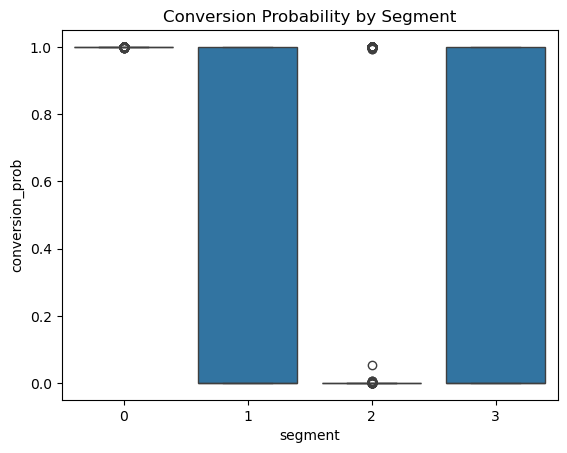

In [65]:
sns.boxplot(x='segment', y='conversion_prob', data=df)
plt.title("Conversion Probability by Segment")
plt.show()